In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random

from sklearn import cluster, metrics


from matplotlib.patches import Patch

import cooler 
import cooltools
from matplotlib.colors import LogNorm
import cooltools.lib.plotting
from matplotlib.backends.backend_pdf import PdfPages

from functools import reduce 

import re
#from collections import Counter
import ast 

%cd /home/varshini/uc_analyses/
import utils, matchmaker_functions, loops_txn
%cd /home/varshini/LoopCall_Analysis_Scripts

import pybedtools as pbt
# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 18})

plt.rcParams["legend.frameon"] = False

import bioframe

from coolpuppy import coolpup
from coolpuppy.lib import numutils
from coolpuppy.lib.puputils import divide_pups
from coolpuppy import plotpup
import cooler
import bioframe
import cooltools
from cooltools import expected_cis, expected_trans
from cooltools.lib import plotting

%cd /home/varshini/uc_analyses/
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts
/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
# load coolers, expected values, hg38 arms 
phases= ['Phase1_','Phase2_dedup', 'Phase3_dedup']
expdir = os.path.join('/mnt/md0/varshini/Analysis/Blood', 'microc_expected')
phase_clr_names = [f'/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_{p}merged.250.mcool::resolutions/5000' for p in phases]

#[cooler.fileops.list_coolers(c) for c in phase_clr_names]
phase_clrs = [cooler.Cooler(c) for c in phase_clr_names]
exps = [os.path.join(expdir, f"P_s_{phase}_5000bp_hg38arms.tsv") for phase in phases]

hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
    # create a view with chromosome arms using chromosome sizes and definition of centromeres
hg38_arms = bioframe.make_chromarms(hg38_chromsizes,  hg38_cens)

    # select only those chromosomes available in cooler
hg38_arms = hg38_arms[hg38_arms.chrom.isin(phase_clrs[0].chromnames)].reset_index(drop=True)
hg38_arms = hg38_arms[~hg38_arms["chrom"].isin(['chrY','chrM'])]

In [3]:
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/'
subdir = 'erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed'
track = pd.read_csv(os.path.join(datapath, subdir), sep='\t')

In [4]:
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v4/supp8"

if not os.path.exists(savedir):
    os.mkdir(savedir)

In [6]:
from matplotlib import colors

In [16]:
log_min = colors.LogNorm(0.71,1.4)


In [17]:
log_min

230.83262221755564


INFO:coolpuppy:('chr5_p', 'chr5_p'): 32
INFO:coolpuppy:('chr4_p', 'chr4_p'): 52
INFO:coolpuppy:('chr8_p', 'chr8_p'): 52
INFO:coolpuppy:('chr7_p', 'chr7_p'): 81
INFO:coolpuppy:('chr6_p', 'chr6_p'): 178
INFO:coolpuppy:('chr2_p', 'chr2_p'): 150
INFO:coolpuppy:('chr3_p', 'chr3_p'): 130
INFO:coolpuppy:('chr8_q', 'chr8_q'): 111
INFO:coolpuppy:('chr1_p', 'chr1_p'): 270
INFO:coolpuppy:('chr7_q', 'chr7_q'): 135
INFO:coolpuppy:('chr9_p', 'chr9_p'): 51
INFO:coolpuppy:('chr6_q', 'chr6_q'): 101
INFO:coolpuppy:('chr5_q', 'chr5_q'): 195
INFO:coolpuppy:('chr10_p', 'chr10_p'): 56
INFO:coolpuppy:('chr4_q', 'chr4_q'): 109
INFO:coolpuppy:('chr12_p', 'chr12_p'): 50
INFO:coolpuppy:('chr3_q', 'chr3_q'): 152
INFO:coolpuppy:('chr11_p', 'chr11_p'): 92
INFO:coolpuppy:('chr9_q', 'chr9_q'): 135
INFO:coolpuppy:('chr13_q', 'chr13_q'): 94
INFO:coolpuppy:('chr10_q', 'chr10_q'): 148
INFO:coolpuppy:('chr1_q', 'chr1_q'): 214
INFO:coolpuppy:('chr2_q', 'chr2_q'): 187
INFO:coolpuppy:('chr18_p', 'chr18_p'): 29
INFO:coolpuppy

128.69061961772738


INFO:coolpuppy:('chr5_p', 'chr5_p'): 34
INFO:coolpuppy:('chr4_p', 'chr4_p'): 37
INFO:coolpuppy:('chr8_p', 'chr8_p'): 60
INFO:coolpuppy:('chr7_p', 'chr7_p'): 87
INFO:coolpuppy:('chr6_p', 'chr6_p'): 154
INFO:coolpuppy:('chr2_p', 'chr2_p'): 131
INFO:coolpuppy:('chr3_p', 'chr3_p'): 153
INFO:coolpuppy:('chr8_q', 'chr8_q'): 121
INFO:coolpuppy:('chr1_p', 'chr1_p'): 289
INFO:coolpuppy:('chr7_q', 'chr7_q'): 136
INFO:coolpuppy:('chr6_q', 'chr6_q'): 110
INFO:coolpuppy:('chr9_p', 'chr9_p'): 39
INFO:coolpuppy:('chr5_q', 'chr5_q'): 187
INFO:coolpuppy:('chr10_p', 'chr10_p'): 58
INFO:coolpuppy:('chr4_q', 'chr4_q'): 119
INFO:coolpuppy:('chr12_p', 'chr12_p'): 73
INFO:coolpuppy:('chr3_q', 'chr3_q'): 132
INFO:coolpuppy:('chr11_p', 'chr11_p'): 85
INFO:coolpuppy:('chr9_q', 'chr9_q'): 166
INFO:coolpuppy:('chr13_q', 'chr13_q'): 69
INFO:coolpuppy:('chr1_q', 'chr1_q'): 232
INFO:coolpuppy:('chr10_q', 'chr10_q'): 128
INFO:coolpuppy:('chr2_q', 'chr2_q'): 163
INFO:coolpuppy:('chr18_p', 'chr18_p'): 20
INFO:coolpuppy

74.58044034019319


...

INFO:coolpuppy:('chr5_p', 'chr5_p'): 131
INFO:coolpuppy:('chr4_p', 'chr4_p'): 202
INFO:coolpuppy:('chr8_p', 'chr8_p'): 227
INFO:coolpuppy:('chr7_p', 'chr7_p'): 318
INFO:coolpuppy:('chr6_p', 'chr6_p'): 622
INFO:coolpuppy:('chr3_p', 'chr3_p'): 524
INFO:coolpuppy:('chr2_p', 'chr2_p'): 588
INFO:coolpuppy:('chr8_q', 'chr8_q'): 400
INFO:coolpuppy:('chr7_q', 'chr7_q'): 477
INFO:coolpuppy:('chr1_p', 'chr1_p'): 1106
INFO:coolpuppy:('chr9_p', 'chr9_p'): 174
INFO:coolpuppy:('chr6_q', 'chr6_q'): 425
INFO:coolpuppy:('chr10_p', 'chr10_p'): 182
INFO:coolpuppy:('chr5_q', 'chr5_q'): 712
INFO:coolpuppy:('chr4_q', 'chr4_q'): 431
INFO:coolpuppy:('chr12_p', 'chr12_p'): 239
INFO:coolpuppy:('chr3_q', 'chr3_q'): 575
INFO:coolpuppy:('chr11_p', 'chr11_p'): 345
INFO:coolpuppy:('chr9_q', 'chr9_q'): 595
INFO:coolpuppy:('chr13_q', 'chr13_q'): 368
INFO:coolpuppy:('chr10_q', 'chr10_q'): 575
INFO:coolpuppy:('chr14_q', 'chr14_q'): 609
INFO:coolpuppy:('chr17_p', 'chr17_p'): 247
INFO:coolpuppy:('chr16_p', 'chr16_p'): 341

7.006370296409214


INFO:coolpuppy:('chr5_p', 'chr5_p'): 118
INFO:coolpuppy:('chr4_p', 'chr4_p'): 222
INFO:coolpuppy:('chr8_p', 'chr8_p'): 254
INFO:coolpuppy:('chr7_p', 'chr7_p'): 316
INFO:coolpuppy:('chr6_p', 'chr6_p'): 584
INFO:coolpuppy:('chr3_p', 'chr3_p'): 528
INFO:coolpuppy:('chr2_p', 'chr2_p'): 639
INFO:coolpuppy:('chr8_q', 'chr8_q'): 511
INFO:coolpuppy:('chr7_q', 'chr7_q'): 491
INFO:coolpuppy:('chr1_p', 'chr1_p'): 972
INFO:coolpuppy:('chr9_p', 'chr9_p'): 176
INFO:coolpuppy:('chr6_q', 'chr6_q'): 518
INFO:coolpuppy:('chr10_p', 'chr10_p'): 213
INFO:coolpuppy:('chr5_q', 'chr5_q'): 722
INFO:coolpuppy:('chr4_q', 'chr4_q'): 486
INFO:coolpuppy:('chr12_p', 'chr12_p'): 235
INFO:coolpuppy:('chr11_p', 'chr11_p'): 339
INFO:coolpuppy:('chr3_q', 'chr3_q'): 659
INFO:coolpuppy:('chr9_q', 'chr9_q'): 603
INFO:coolpuppy:('chr13_q', 'chr13_q'): 390
INFO:coolpuppy:('chr10_q', 'chr10_q'): 532
INFO:coolpuppy:('chr16_p', 'chr16_p'): 307
INFO:coolpuppy:('chr17_p', 'chr17_p'): 251
INFO:coolpuppy:('chr2_q', 'chr2_q'): 754
IN

6.021679549895522


INFO:coolpuppy:('chr5_p', 'chr5_p'): 107
INFO:coolpuppy:('chr4_p', 'chr4_p'): 179
INFO:coolpuppy:('chr8_p', 'chr8_p'): 222
INFO:coolpuppy:('chr7_p', 'chr7_p'): 336
INFO:coolpuppy:('chr6_p', 'chr6_p'): 598
INFO:coolpuppy:('chr3_p', 'chr3_p'): 487
INFO:coolpuppy:('chr2_p', 'chr2_p'): 640
INFO:coolpuppy:('chr8_q', 'chr8_q'): 523
INFO:coolpuppy:('chr7_q', 'chr7_q'): 507
INFO:coolpuppy:('chr1_p', 'chr1_p'): 1018
INFO:coolpuppy:('chr9_p', 'chr9_p'): 206
INFO:coolpuppy:('chr6_q', 'chr6_q'): 560
INFO:coolpuppy:('chr5_q', 'chr5_q'): 776
INFO:coolpuppy:('chr10_p', 'chr10_p'): 215
INFO:coolpuppy:('chr4_q', 'chr4_q'): 553
INFO:coolpuppy:('chr12_p', 'chr12_p'): 265
INFO:coolpuppy:('chr3_q', 'chr3_q'): 644
INFO:coolpuppy:('chr11_p', 'chr11_p'): 302
INFO:coolpuppy:('chr9_q', 'chr9_q'): 527
INFO:coolpuppy:('chr13_q', 'chr13_q'): 504
INFO:coolpuppy:('chr10_q', 'chr10_q'): 533
INFO:coolpuppy:('chr16_p', 'chr16_p'): 285
INFO:coolpuppy:('chr14_q', 'chr14_q'): 621
INFO:coolpuppy:('chr17_p', 'chr17_p'): 189

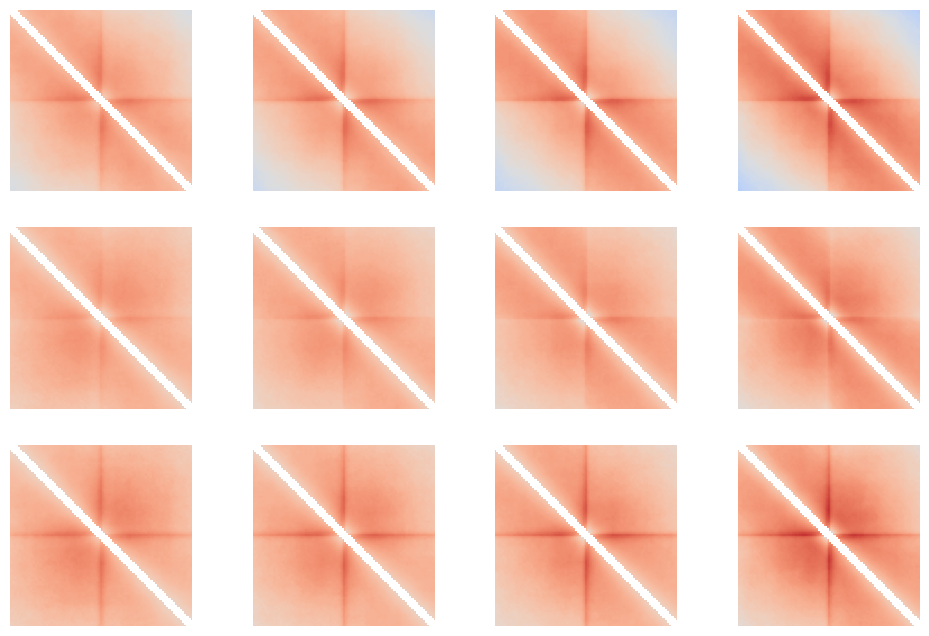

In [24]:
# everything together 

fnames = ["H3K27ac_consensus_narrow_mean_P2_v1_score.bed",
                "H3K4me1_consensus_broad_mean_P2_v1_score.bed",
                "P1_H3K27ac_q0.01_peaks_mean_P1_v1_score.bed",
                "P1_H3K4me1_q0.01_peaks_mean_P1_v1_score.bed"]

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(12, 8),
    sharex=True,
    sharey=True
)
log_min = np.log10(0.71)
log_max =  np.log10(1.4)


for fname in fnames:
    enh_regions = pd.read_csv(os.path.join(datapath, "genomic_features", fname),
                         sep="\t",names=['chrom','start','end','score'])
    enh_regions.drop(enh_regions[enh_regions['score']==0].index,axis=0, inplace=True)
    
    track['chrom'] = track['chr']
    track['start'] = track['coord'].astype(int)-100
    track['end'] = track['coord'].astype(int)+100
    track_sub = track[['chrom','start','end','triangle_score_P3','quant']]
    
    mm = pbt.BedTool.from_dataframe(track_sub)
    enh = pbt.BedTool.from_dataframe(enh_regions)
    mm_enh =  mm.intersect(enh, wb=True).to_dataframe(header=None)

    mm_enh['itemRgb']
#     print(mm_enh['itemRgb'].min())
#     print(mm_enh['itemRgb'].quantile(0.1))
#     plt.hist(mm_enh['itemRgb'], bins=200)
#     plt.axvline(mm_enh['itemRgb'].quantile(0.1), color='r')
#     plt.show()


    track_pup = enh_regions[enh_regions['score']>mm_enh['itemRgb'].quantile(0.1)]
    track_pup['quant'] = pd.qcut(track_pup['score'], 4, labels=False)
    for p in [0, 1, 2]:
        for quant in track_pup['quant'].unique():
            ax = axes[p, quant]
            track_pup_sub = track_pup[track_pup['quant']==quant]
            print(track_pup_sub['score'].mean())
            
            clr = phase_clrs[p]
            exp0 =  pd.read_csv(exps[p], sep='\t')

            pup_control_incl = coolpup.pileup(clr, track_pup_sub, features_format='bed', local=True, view_df=hg38_arms,
                                         flank=200_000, expected_df = exp0, min_diag=0, nproc=8)
            mat = pup_control_incl["data"][0]  

            ax.imshow(
                mat,
                cmap="coolwarm",
                norm=colors.LogNorm(vmin=0.71, vmax=1.4),  
            )
            ax.set_axis_off()
            #fg.fig.suptitle(f"Phase {p+1}, quant {quant}, {fname}")
    plt.savefig(os.path.join(savedir, f"{fname}_all.svg"))

In [21]:
ax.imshow(
                mat,
                cmap="coolwarm",
                norm=colors.LogNorm(vmin=0.71, vmax=1.4),  
            )
plt.show()

In [5]:
# everything together 

fnames = ["H3K27ac_consensus_narrow_mean_P2_v1_score.bed",
                "H3K4me1_consensus_broad_mean_P2_v1_score.bed",
                "P1_H3K27ac_q0.01_peaks_mean_P1_v1_score.bed",
                "P1_H3K4me1_q0.01_peaks_mean_P1_v1_score.bed"]


for fname in fnames:
    enh_regions = pd.read_csv(os.path.join(datapath, "genomic_features", fname),
                         sep="\t",names=['chrom','start','end','score'])
    enh_regions.drop(enh_regions[enh_regions['score']==0].index,axis=0, inplace=True)
    
    track['chrom'] = track['chr']
    track['start'] = track['coord'].astype(int)-100
    track['end'] = track['coord'].astype(int)+100
    track_sub = track[['chrom','start','end','triangle_score_P3','quant']]
    
    mm = pbt.BedTool.from_dataframe(track_sub)
    enh = pbt.BedTool.from_dataframe(enh_regions)
    mm_enh =  mm.intersect(enh, wb=True).to_dataframe(header=None)

    mm_enh['itemRgb']
#     print(mm_enh['itemRgb'].min())
#     print(mm_enh['itemRgb'].quantile(0.1))
#     plt.hist(mm_enh['itemRgb'], bins=200)
#     plt.axvline(mm_enh['itemRgb'].quantile(0.1), color='r')
#     plt.show()
    
    track_pup = enh_regions[enh_regions['score']>mm_enh['itemRgb'].quantile(0.1)]
    track_pup['quant'] = pd.qcut(track_pup['score'], 4, labels=False)
    for p in [0, 1, 2]:
        for quant in track_pup['quant'].unique():
            print(f"QUANT: {quant}")
            track_pup_sub = track_pup[track_pup['quant']==quant]
            print(track_pup_sub['score'].mean())

QUANT: 3
230.83262221755564
QUANT: 2
128.69061961772738
QUANT: 1
74.58044034019319
QUANT: 0
47.853759239815204
QUANT: 3
230.83262221755564
QUANT: 2
128.69061961772738
QUANT: 1
74.58044034019319
QUANT: 0
47.853759239815204
QUANT: 3
230.83262221755564
QUANT: 2
128.69061961772738
QUANT: 1
74.58044034019319
QUANT: 0
47.853759239815204
QUANT: 3
80.70897817853923
QUANT: 2
57.144944860234446
QUANT: 1
49.19341830477908
QUANT: 0
44.45846363841298
QUANT: 3
80.70897817853923
QUANT: 2
57.144944860234446
QUANT: 1
49.19341830477908
QUANT: 0
44.45846363841298
QUANT: 3
80.70897817853923
QUANT: 2
57.144944860234446
QUANT: 1
49.19341830477908
QUANT: 0
44.45846363841298
QUANT: 3
32.11680562157693
QUANT: 2
17.662910757466157
QUANT: 1
11.124984973648859
QUANT: 0
8.22434192725018
QUANT: 3
32.11680562157693
QUANT: 2
17.662910757466157
QUANT: 1
11.124984973648859
QUANT: 0
8.22434192725018
QUANT: 3
32.11680562157693
QUANT: 2
17.662910757466157
QUANT: 1
11.124984973648859
QUANT: 0
8.22434192725018
QUANT: 3
11.2

In [36]:
fg.fig.suptitle(f"Phase {p+1}, quant {quant}, {fname}")

Text(0.5, 0.98, 'Phase 1, quant 3, H3K27ac_consensus_narrow_mean_P2_v1_score.bed')

In [38]:
enh_regions = pd.read_csv(os.path.join(datapath, "genomic_features/H3K4me1_consensus_broad_mean_P2_v1_score.bed"),
                         sep="\t",names=['chrom','start','end','score'])
enh_regions.drop(enh_regions[enh_regions['score']==0].index,axis=0, inplace=True)

In [39]:
enh_regions

,chrom,start,end,score
0,chr12,53007864,53007872,NaN
1,chr20,23129656,23129662,NaN
2,chr9,32885579,32885582,NaN
3,chr6,144886274,144886278,NaN
4,chr12,68331264,68331268,NaN
...,...,...,...,...
30784,chr4,99892957,99892998,15.0000
30785,chr21,45416541,45416612,14.4700
30786,chr17,18781070,18781457,13.8475
30787,chr7,2303140,2303422,13.1533


In [42]:
track_sub

,chrom,start,end,triangle_score_P1,quant
0,chr1,1024227,1024427,1.139807,2
1,chr1,1715337,1715537,1.132361,2
2,chr1,1728657,1728857,0.965163,1
3,chr1,2199315,2199515,0.494884,0
4,chr1,2278158,2278358,1.842449,3
...,...,...,...,...,...
3319,chrX,153985601,153985801,0.852364,1
3320,chrX,154473025,154473225,1.745329,3
3321,chrX,154484621,154484821,1.527788,3
3322,chrX,154495604,154495804,1.351207,2


In [43]:
mm = pbt.BedTool.from_dataframe(track_sub)
enh = pbt.BedTool.from_dataframe(enh_regions)
mm_enh =  mm.intersect(enh, wb=True).to_dataframe(header=None)

mm_enh.groupby('score').agg('itemRgb').mean()

In [46]:
mm_enh

,chrom,start,end,name,score,strand,thickStart,thickEnd,itemRgb
0,chr1,1024227,1024427,1.139807,2,chr1,1022631,1025756,128.2810
1,chr1,2199315,2199515,0.494884,0,chr1,2198517,2200203,81.0236
2,chr1,2278158,2278358,1.842449,3,chr1,2278135,2278538,28.2500
3,chr1,2345708,2345908,1.092618,1,chr1,2344560,2346997,87.1344
4,chr1,2560745,2560945,0.958675,1,chr1,2560131,2562156,46.5467
...,...,...,...,...,...,...,...,...,...
3037,chrX,153985601,153985801,0.852364,1,chrX,153983723,153987118,171.6340
3038,chrX,154473025,154473225,1.745329,3,chrX,154472879,154473809,27.5522
3039,chrX,154484621,154484821,1.527788,3,chrX,154483728,154487383,173.0640
3040,chrX,154495604,154495804,1.351207,2,chrX,154492687,154497325,116.2700


score
0    110.738915
1    106.988005
2    110.812004
3    125.482169
Name: itemRgb, dtype: float64

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='score', ylabel='itemRgb'>

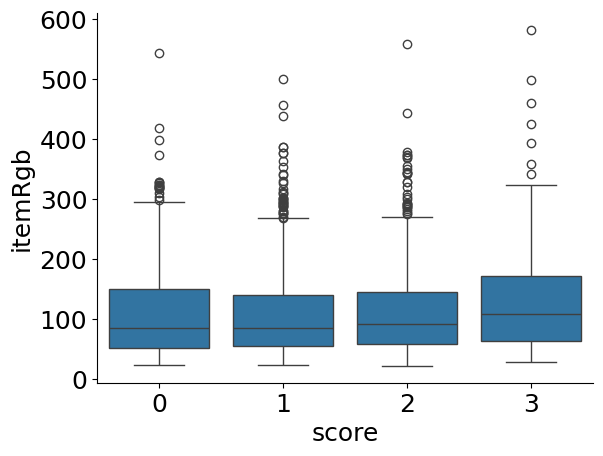

In [48]:
sns.boxplot(mm_enh, x='score', y='itemRgb')

(array([1.000e+00, 1.200e+01, 1.790e+02, 1.731e+03, 4.462e+03, 4.301e+03,
        2.790e+03, 1.707e+03, 1.275e+03, 9.960e+02, 7.960e+02, 7.030e+02,
        6.400e+02, 5.930e+02, 5.470e+02, 4.940e+02, 5.020e+02, 4.300e+02,
        4.580e+02, 4.260e+02, 4.610e+02, 4.180e+02, 3.950e+02, 4.390e+02,
        3.730e+02, 3.500e+02, 3.530e+02, 3.500e+02, 3.190e+02, 3.320e+02,
        2.920e+02, 2.770e+02, 2.620e+02, 2.260e+02, 2.090e+02, 2.200e+02,
        2.100e+02, 1.870e+02, 1.800e+02, 1.480e+02, 1.400e+02, 1.410e+02,
        1.150e+02, 1.080e+02, 8.100e+01, 1.150e+02, 9.000e+01, 8.600e+01,
        7.400e+01, 6.900e+01, 5.600e+01, 5.800e+01, 5.800e+01, 4.000e+01,
        4.800e+01, 3.700e+01, 3.000e+01, 2.500e+01, 3.000e+01, 2.600e+01,
        3.100e+01, 2.200e+01, 1.400e+01, 1.800e+01, 1.500e+01, 1.100e+01,
        1.400e+01, 1.000e+01, 1.500e+01, 1.300e+01, 8.000e+00, 2.000e+00,
        1.100e+01, 6.000e+00, 8.000e+00, 5.000e+00, 3.000e+00, 5.000e+00,
        1.000e+00, 4.000e+00, 1.000e+0

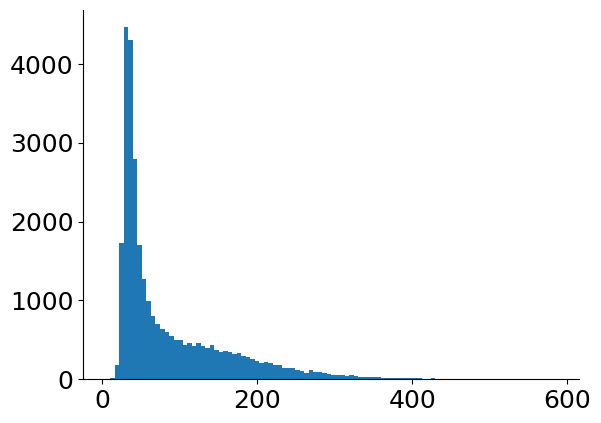

In [49]:
plt.hist(enh_regions['score'], bins=100)

